# Zaks et al. 2012 — strict-source MxlPy port and figure reruns

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mxlmodels import get_zaks2012
from mxlpy import Model, Simulator, make_protocol

In [8]:
from mxlpy.integrators import Scipy
from functools import partial


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [39]:
import numpy as np

def cat_pam(vin, nreps):
    return np.tile(np.asarray(vin, dtype=float), nreps)

def setup_pam_intensities(act, Isat=7000, flashlength=0.5, simtype=1):
    Imeasure = 0.001

    PAMintens = np.array([act, Isat, act], dtype=float)
    PAMdurat28 = np.array([28, flashlength, 2 - flashlength], dtype=float)
    PAMdurat58 = np.array([58, flashlength, 2 - flashlength], dtype=float)
    PAMdurat15 = np.array([13.0, flashlength, 2 - flashlength], dtype=float)
    PAMdurat7 = np.array([7.0, flashlength, 2 - flashlength], dtype=float)

    offintens = np.array([Imeasure, Isat, Imeasure], dtype=float)
    offintensnosat = np.array([Imeasure, Isat, Imeasure], dtype=float)
    fidx = np.array([0, 1, 0], dtype=int)

    if simtype == 1:
        LightIntensities = np.concatenate([
            offintens,
            [Imeasure, Isat],
            cat_pam(PAMintens, 23),
            cat_pam(offintensnosat, 15),
        ])

        durat = np.concatenate([
            PAMdurat58,
            [60, flashlength],
            cat_pam(PAMdurat7, 2),
            cat_pam(PAMdurat15, 10),
            cat_pam(PAMdurat28, 4),
            cat_pam(PAMdurat58, 7),
            cat_pam(PAMdurat7, 2),
            cat_pam(PAMdurat28, 3),
            cat_pam(PAMdurat58, 10),
        ])

        flashyesno = np.concatenate([
            fidx,
            [0, 1],
            cat_pam(fidx, 30),
        ])

    elif simtype == 2:
        raise ValueError("this case doesnt work right now")
    else:
        raise ValueError("simtype must be 1 or 2")

    flashidx = np.where(flashyesno != 0)[0]
    return LightIntensities, durat, flashidx

In [40]:
def calc_pam_vals2(
    fluo_result: pd.Series, protocol: pd.DataFrame, pfd_str: str = "pfd", sat_pulse: float = 5000
) -> pd.DataFrame:
    """Calculate PAM values from fluorescence data.

    Use the fluorescence data from a PAM protocol to calculate Fm, NPQ. To find the Fm values, the protocol used for simulation is seperated into ranges between each saturating pulse. Then the maximum fluorescence value within each range is taken as Fm. Thes are then used to calculate NPQ.

    Args:
        fluo_result (pd.Series): Fluorescence data as a pd.Series from mxlpy simulation.
        protocol (pd.DataFrame): PAM protocol used for simulation. Created using make_protocol from mxlpy.
        pfd_str (str): The name of the PPFD parameter in the protocol.
        sat_pulse (float, optional): The threshold for saturating pulse in the protocol. Defaults to 2000.

    Returns:
        tuple[pd.Series, pd.Series]: Fm and NPQ as pd.Series
    """    
    fluo_result = fluo_result.div(fluo_result.max()).fillna(0)

    # Step 0: Ensure that protocol has same index as fluo_results
    name = fluo_result.name
    # common_index = protocol.index.union(fluo_result.index).sort_values()
    merged = pd.concat([protocol, fluo_result], axis = 1).sort_index().bfill()
    # Step 1: Find all periods that has pfd = SP

    grp = (merged[pfd_str] != merged[pfd_str].shift()).cumsum()
    groups_sp = merged[grp.isin(grp[merged[pfd_str] == sat_pulse])]
    peaks = [g for _, g in groups_sp.groupby(grp[groups_sp.index])]

    # Step 2: Fm is the max fluo value of each SP period

    Fm = pd.Series(
        [k[name].max() for k in peaks],
        index= [k[name].idxmax() for k in peaks],
    )
    Fm.name = "Fm"
    # Step 3: Fs is the fluo value right before the start of SP period
    idx_null = [k[name].index[0] for k in peaks]
    Fs = merged.iloc[merged.index.get_indexer(pd.Index(idx_null)) -1][name]
    Fs.name = "Fs"
    
    # Calculate NPQ
    NPQ = (Fm.iloc[0] - Fm) / Fm if len(Fm) > 0 else pd.Series(dtype=float)
    NPQ.name = "Non-Photochemical Quenching (NPQ)"

    # Quantum Yield of Non-Regulated Energy Loss (Y(NO))
    Y_NO = Fs / Fm.iloc[0] if len(Fm) > 0 else pd.Series(dtype=float)
    Y_NO.name = "Y(NO)"

    # Quantum Yield of Photochemical Energy Conversion (Y(II))
    Y_II = (Fm.values - Fs) / Fm.values if len(Fm) > 0 else pd.Series(dtype=float)
    Y_II.name = "Y(II)"
    
    quant_yields = pd.concat([s.reset_index(drop=True) for s in [Fm, Fs, Y_NO, NPQ, Y_II]], axis=1)
    quant_yields["Fm_index"] = Fm.index
    quant_yields["Fs_index"] = Fs.index
    quant_yields.index = pd.Index([0] + list(protocol[protocol["pfd"] != sat_pulse].index[1:-1]))# Reset as the first and last index of protocol is artifically modifified so the model can do simulation
    quant_yields["NPQ_Phi2_index"] = quant_yields.index
    
    return quant_yields

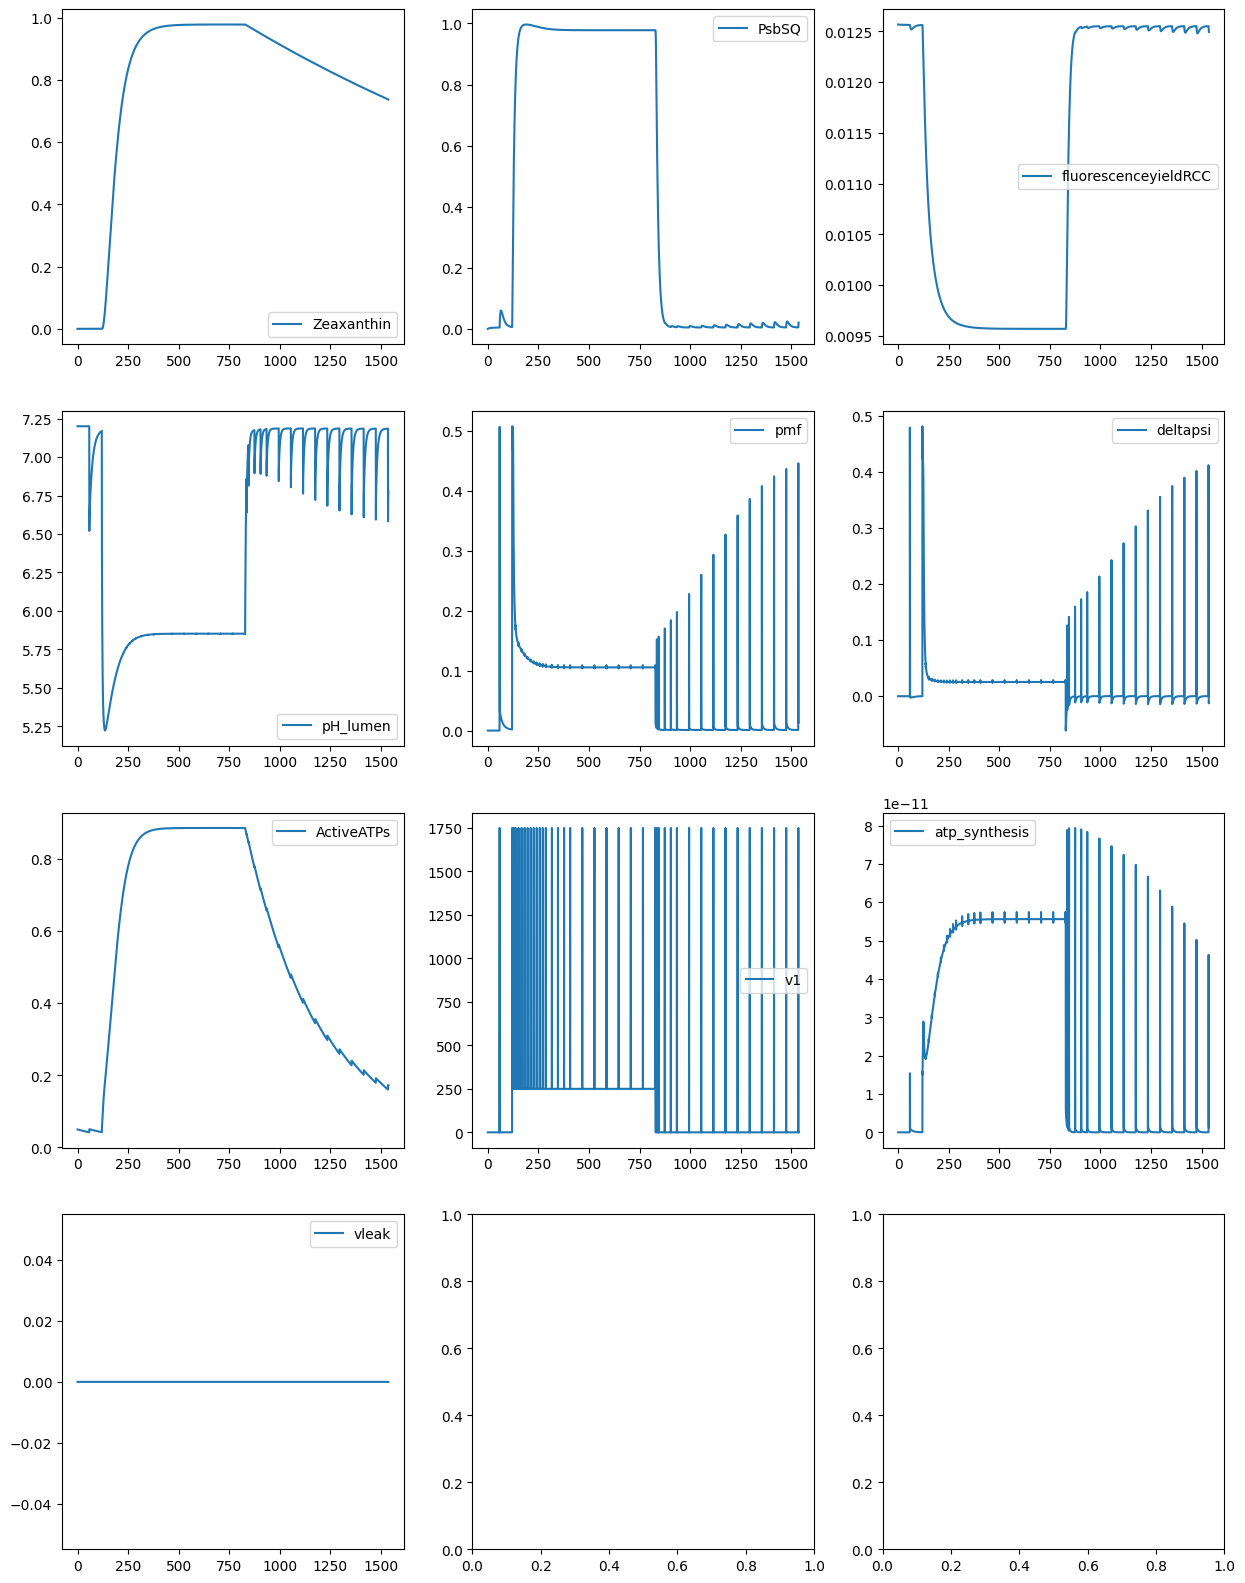

In [42]:
LightIntensities, durat, flashidx = setup_pam_intensities(act=1000)

protocol = make_protocol(
    [
        (i, {"LightIntensity": k}) for i,k in zip(durat, LightIntensities)
    ] 
)

res = Simulator(get_zaks2012(),
                integrator=partial(Scipy, method="Radau",   # or "BDF" for stiff problems
                rtol=1e-8,
                atol=1e-10,
            ),
                ).simulate_protocol(protocol, time_points_per_step=100).get_result().unwrap_or_err().get_combined()


name = ["Zeaxanthin", "PsbSQ", "fluorescenceyieldRCC", 
        "pH_lumen", "pmf", "deltapsi","ActiveATPs", "v1", "atp_synthesis", "vleak"]#get_zaks2012().get_readout_names()

ncol = 3
nrow = int(len(name)/ncol) + 1
idx = res.index
fig, axs = plt.subplots(ncols=ncol, nrows=nrow, figsize = (ncol*5, nrow*5))
axx = axs.flatten()
for var, ax in zip(name, axs.flatten()):
    ax.plot(idx, res[var], label = var)
    ax.legend()
    ymax = 1e-3
    # add_light_bar(ax, y=ymax*0.95, height = 1e-3)
plt.savefig("test.png")
plt.show()